# PCHN63101 Workshop 1: Statistical Modelling
In the accompanying lesson to this workshop we explored the general concept of a statistical model as a method of capturing the variance inherent within a dataset. We first saw how to define a descriptive measure of variance, before exploring how this notion of random variation can be formalised using concepts from the world of *probability*. Specifically, every value we measure is conceptualised as a random draw from a particular probability distribution. This distribution provides the *model* of our data-generating process and thus formalises the probabilistic behaviour of our measurements. The shape of every probability distribution is controlled by a number of *parameters* that, either directly or indirectly, inform the *expected value* and *variance* of the distribution. These can be thoughts of as the *most probable* value and the *width*. A statistical model is then concerned with assuming some population distribution for a given data set and then connecting the parameters of the distribution to the data via a *mean function* and a *variance* function.    

At present, some of these ideas may feel a bit abstract. However, over the coming weeks we will start to see them put into action and all this information should become more concrete. In this workshop, the focus will be on providing more intuition about all these topics. In part, this will involve demonstrating some of these ideas in code so that you can play around with them, get a feel for them and see how the output changes with different inputs and arguments. In general, playing with code is one of the *best* ways for gaining intuition about more abstract mathematical concepts.

## Sources of Variance
To begin, we will start with the basic concept of variance as the degree to which measured datapoints *differ* from each other. You should understand from the lesson one way in which we can capture this degree of variation, through the calculation of the sample variance. However, capturing variance is only ever a precursor to trying to *explain* variance. A core concept here is that data can vary for *two* reasons: systematic patterns, or random noise. Consider the code below and the resultant plots

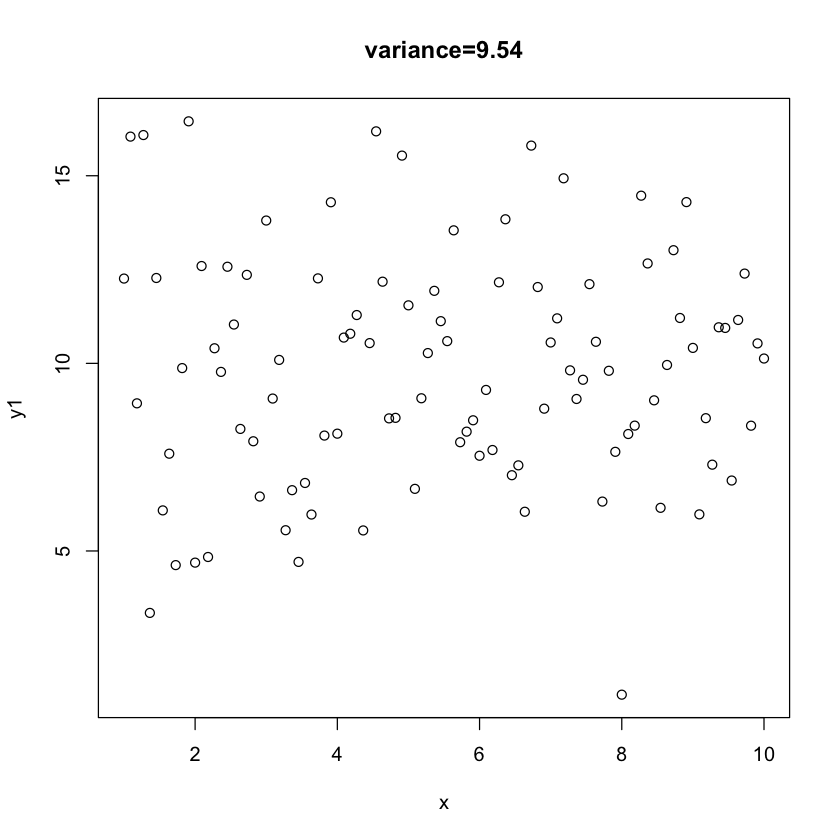

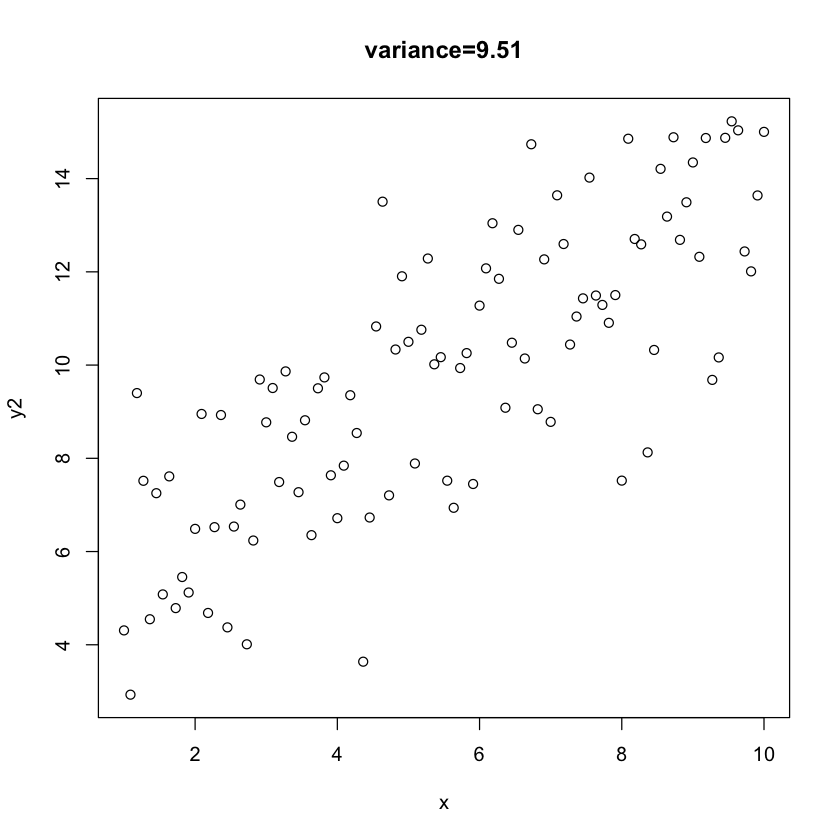

In [57]:
set.seed(666)
x <- seq(1, 10, length.out = 100)

y1 <- rnorm(100, 10, 3)                 # pure noise
y2 <- (5 + 0.9*x) + rnorm(100, 0, 1.68) # linear pattern + pure noise

var1 <- round(var(y1),2)
var2 <- round(var(y2),2)

plot(x, y1, main=paste0("variance=",var1)) 
plot(x, y2, main=paste0("variance=",var2))


The first plot contains random noise drawn from $\mathcal{N}\left(10,3\right)$, which is completely unrelated to the predictor variable $x$. The second plot contains a linear pattern between $x$ and $y$, with some random noise added. Both sets of data have nearly the same measurment of variance, yet the second one has a much clearer pattern between $x$ and $y$. This highlights that variance in and of itself cannot tell us whether the variation is systematic or random. That is the job of the statistical model. Any patterns within the data are taken as the *predictable* elements, whereas the additional random noise represents the *unpredictable* elements. The job of any statistical model is to take the total amount of variance in the data and try to *split it* into the amount attributable to predictable patterns, and the amount attributable to random noise.

<div class="alert alert-block alert-info"> 
<b>ACTIVITY</b> Imagine that the second plot above corresponds to an investigation into how mood, as measured using a questionnaire, improves based on the number of hours sleep someone gets the night before. If $y$ is mood and $x$ is hours of sleep, what does the systematic pattern in the data represent? What would you attribute this source of variance to? What about the noise? Why doesn't all the data perfectly adhere to the systematic pattern?
</div>

### Reducible and Irriducible Error
The idea of splitting variance into a *systematic* component and a *random noise* component relates to a key idea in statistics of *reducible* and *irriducible* error. For example, using the sleep and mood example, if we measured mood but had not measured hours of sleep, we would have no way of capturing the relationship we see above. The variance associated with this relationship would therefore get partitioned into the *random noise* component and the model error would be larger. However, if we include hours of sleep in our model, this relationship is captured, the *systematic* variance gets larger and the *random noise* gets smaller. We have therefore *reduced* the model error and so this is an example of *reducible* error. However, even with every measurement in the world we could never capture all the reasons why data varies, as there will always be some element that is just random noise. This is the *irreducible error*. We cannot get rid of it by making our model better and better because there will always be some element of real-world data that cannot be predicted. Our aim when building a statistical model is therefore to account for as much reducible error as possible, knowing that there will always be some amount of irreducible error.

## Random Variables as Variance Generators
When conceptualising our measurements as realisations of a random variable, we can think of the random variable as the *variance generator*. The variance in our data comes from the fact that the variable is random and can be captured by understanding the *shape* of its probability distribution. Of course, the probability distribution is a mathematical idealisation of the real world. So it is perhaps more accurate to say that the random variable is a *model* of the variance we observe in real data. The distribution is our proposed *data-generating process* in that it captures where the data came from. As such, understanding the nature of probability disributions is central to statistical modelling.  

### Discrete Outcome Example
Imagine an experiment where subjects are exposed to a series of very faint auditory stimuli. After each presentation, they are asked whether they heard anything or not. In total, each subject takes part in 20 trials, where the outcome variable is a count of the number of "yes" responses. This variable can be modelled as a *binomial random variate* of the form

$$
y_{i} \sim \mathcal{B}\left(n,p\right).
$$

We already know that $n=20$, because each subject takes part in 20 trials. What would be unknown in reality would be the probability of giving a "yes" response. Let us say, for the purpose of illustration, that we know that the stimuli are around around 60% detectable, so $p=0.6$. Thus, our proposed data-generating process is

$$
y_{i} \sim \mathcal{B}\left(20,0.6\right).
$$

Here, the variation in the count of "yes" responses across subjects is generated by the fact that this is a Binomial random variate drawn from a distribution with a *mean* and *variance*. These elements control both what the average count of "yes" responses is, as well as how variable this count will be on average. Thus, everything we need to know about this experiment is captured in the data-generating model above.

We can use `R` to simulate data like this. For instance, we can generate 100 subjects from this experiment like so

In [15]:
y <- rbinom(n=100, size=20, prob=0.6)
y

[1] 11 15 11  9 10 13 13 11 14 11 14 14 14 15 10 13 13  9 14 13 16 14 15 12 14
 [26] 11 13 14 13 12 13 14 11 14 13 16 13 13 12 11 11  7 14  8 12  9  7 11 13 12
 [51] 14 13 13 16 16  7 11 12 11 13 12 11 13 14 13  9 16 12  9  9 10 13  9 10  9
 [76] 13 12 13 14 11 10 12 14 13 17 13 13 13 10 12 12  9 15 11 13 11 12 11 10 10

<div class="alert alert-block alert-info"> 
<b>ACTIVITY</b> Try running this code a few times. Do you get the same values? Is there any way to predict what those values will be? Think about what this represents in terms of running an experiment again and again with different subjects.
</div>

It should be clear that we have no way of predicting what any single response will be, nor how this will change from subject to subject. Thus, this variable is *unpredictable* in the short-term. This is the random noise component in action. However, in the *long-term* there is a pattern that we can use to make *general* predictions about the data. This is the systematic component in action. 

Both the *random noise component* and *systematic component* are described by different elements of the probability distribution. The random noise is captured by the *variance* and the systematic pattern is captured by the *expected value* (the *mean*). All probability distributions have some concept of both these elements. For the Binomial distribution, these are linked to the parameters in the following way

$$
\begin{alignat*}{1}
    E(y_{i})   &= np \\
    Var(y_{i}) &= np(1-p)
\end{alignat*}
$$

Thus, we can say how many "yes" responses we expect on average and how variable those responses are expected to be from subject-to-subject on average.

<div class="alert alert-block alert-info"> 
<b>ACTIVITY</b> Create a histogram of the data generated from the binomial distribution above. Try calculating the expected value and variance using the formulas above. Do they appear to agree with what you can see? Try calculating these directly from the data using the <code>mean()</code> and <code>var()</code> functions. Are they close to the values calculated directly from the parameters? What happens if you make the sample size very large (i.e. 10,000)?
</div>

... We conceptualise the effect of this as a shift in the probability of saying "yes". In other words, the experimental manipulation has caused $p$ to change.

### Continuous Outcome Example

### Scaling Random Variables
It is useful to get some sense of how transformations affect the probabilistic information... 

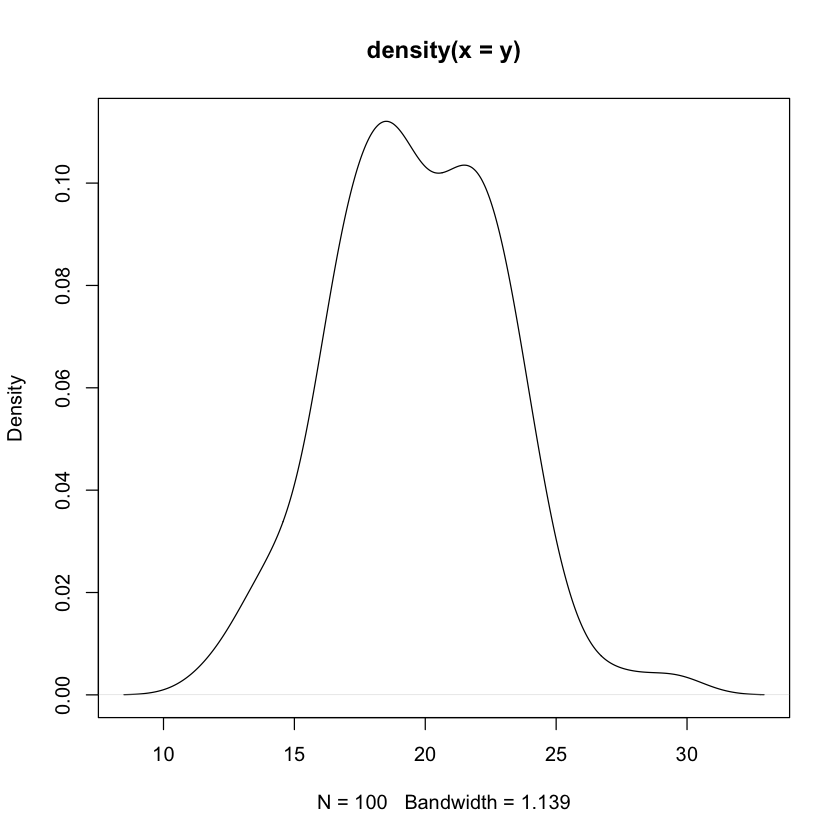

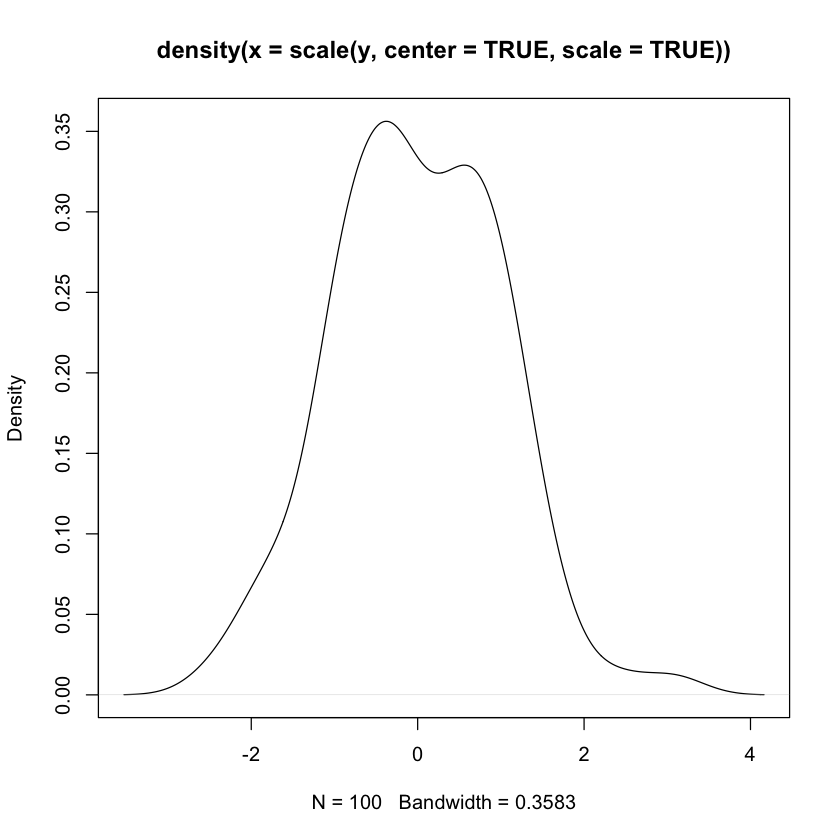

In [26]:
y <- rnorm(n=100, mean=20, sd=3)
plot(density(y))
plot(density(scale(y,center = TRUE, scale=TRUE)))

## Determining Distributions from Data
... As an example, the code below shows 9 examples of drawing data from a normal distribution and then plotting it. In this example, $n = 5$, which is a very small sample. Notice how difficult it is to assess the actual form of distribution from the sample, despite us knowing that each one was drawn from the same distribution.

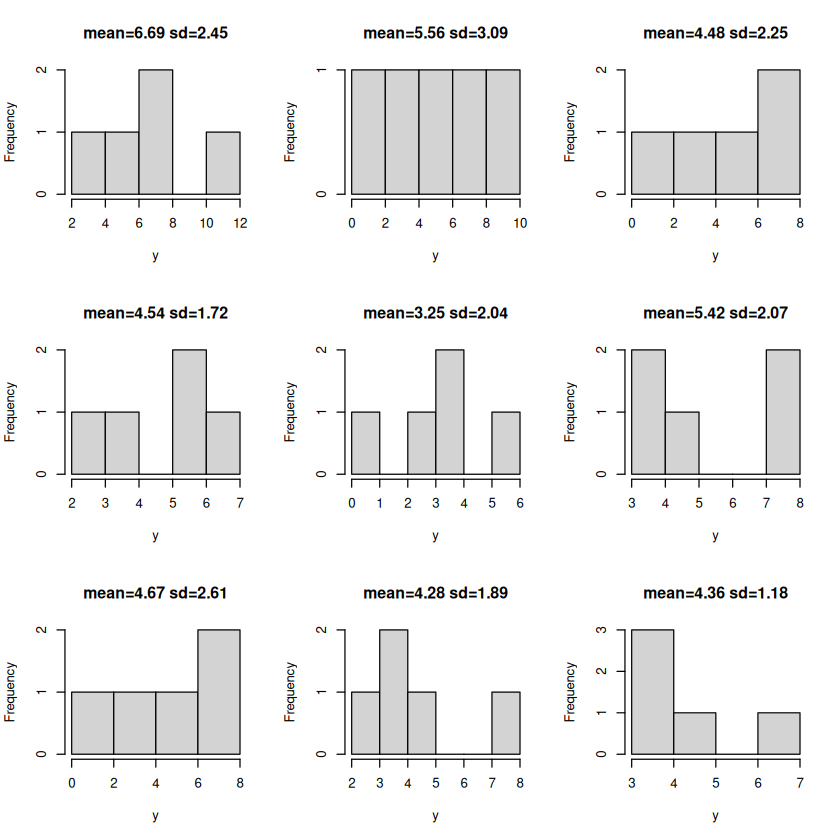

In [12]:
n <- 5
par(mfrow=c(3,3))
for (i in 1:9){
    y     <- rnorm(n, mean=5, sd=2)
    mu    <- mean(y)
    sigma <- sd(y)
    hist(y, main=paste0("mean=",round(mu,2)," sd=",round(sigma,2)))
}

par(mfrow=c(1,1)) # reset the display

<div class="alert alert-block alert-info"> 
<b>ACTIVITY</b> Alter the code above for different values of <code>n</code>. At what sample size do you think assuming normality based on the shape of the sample distribution is reasonable? What does this suggest about how reliable it is to use the basic shape of the sample distribution to determine the population distribution? Now consider how variable the estimates are for the <i>mean</i> and <i>standard deviation</i>, as written in the title of each histogram. Remember, the true values are a mean of 5 and a standard deviation of 2. How does this variability change with different values of <code>n</code> and what does this suggest about our ability to accurately estimate the population parameters from a sample?
</div>

### How Do We Choose a Distribution?

### What If We Get the Distribution Wrong?
... So, remembering the quote from George Box, we will *always* get the distribution "wrong" because the distribution is a *model* and no model is perfect. Our aim is then to choose something that is *as close as possible* such that the numbers produced by the model are useful.

## Mean Functions and Variance Functions
... We can actually use R to define explicit functions for both the mean and variance. This can be helpful because it shows how the principles of the mathematical models translate into code. If you find code easier to understand, this can really help drive the point home.

In [17]:
mean.func <- function(){
    mu <- 5
    return(mu)
}

var.func <- function(){
    sigma2 <- 2
    return(sigma2)
}

Which would be equivalent to the model

$$
\begin{alignat*}{1}
    y_{i}           &\sim \mathcal{N}\left(\mu_{i},\sigma^{2}_{i}\right) \\
    \mu_{i}         &= 5 \\
    \sigma^{2}_{i}  &= 2 
\end{alignat*}
$$

... Now let us alter the mean and variance functions so that the value they return depends upon a predictor variable. This allows the mean and variance to *change* across measurements depending upon some other value.

As a final example, let us see how a simple regression model would be represented in this framework.

In [3]:
mean.func <- function(x){
    beta.0 <- 5
    beta.1 <- 2
    mu     <- beta.0 + beta.1*x
    return(mu)
}

var.func <- function(x){
    sigma2 <- 2
    return(sigma2)
}

<div class="alert alert-block alert-danger">
<b>IMPORTANT</b> The examples here all assume we know the values of the parameters. This is simply to illustrate how statistical models work. In reality, these values will be estimated from the data we have. So, when applied to real data, you can think of replacing the definition of the parameters values with question marks. This gives a <i>form</i> for the mean function and variance function, but these forms depend on values we do not know. The process of <i>fitting</i> or <i>estimating</i> a model is effectively using the data to <i>guess</i> what those values are. We can then replace the question marks with actual numbers.
</div>